# Análisis espacial de humedales de Bogotá
Este Notebook carga, revisa y visualiza capas geográficas relacionadas con los humedales de Bogotá.

# Importación de Bibliotecas

In [1]:
from pathlib import Path

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

print("GeoPandas:", gpd.__version__)

GeoPandas: 1.1.3


# Rutas del Proyecto

In [2]:
ROOT = Path("..")

DATA_RAW = ROOT / "data" / "raw"
DATA_PROCESSED = ROOT / "data" / "processed"
DATA_EXPORTS = ROOT / "data" / "exports"

print("Raw:", DATA_RAW.resolve())
print("Processed:", DATA_PROCESSED.resolve())
print("Exports:", DATA_EXPORTS.resolve())

Raw: D:\00_Portafolio\humedales\data\raw
Processed: D:\00_Portafolio\humedales\data\processed
Exports: D:\00_Portafolio\humedales\data\exports


In [3]:
for archivo in DATA_RAW.rglob("*"):
    print(archivo.name)

.gitkeep
bogota.zip
cober_vege_humedales.zip
mallavialintermedia.zip
pensionadosupz_042023.zip
proyecciones-bogota-UPZ.xlsx
RUNAP.zip
suelo.zip


In [4]:
zip_files=list(DATA_RAW.glob("*.zip"))

for i, archivo in enumerate(zip_files):
    print(f"{i}: {archivo.name}")

0: bogota.zip
1: cober_vege_humedales.zip
2: mallavialintermedia.zip
3: pensionadosupz_042023.zip
4: RUNAP.zip
5: suelo.zip


In [12]:
import zipfile
zip_path = zip_files[1]
with zipfile.ZipFile(zip_path, "r") as z:
    for nombre in z.namelist():
        print(nombre)

#Con base en lo que ponga en el indice ese es el que se plotea.

Cober_vege_humedales.CPG
Cober_vege_humedales.dbf
Cober_vege_humedales.prj
Cober_vege_humedales.sbn
Cober_vege_humedales.sbx
Cober_vege_humedales.shp
Cober_vege_humedales.shp.xml
Cober_vege_humedales.shx


In [15]:
humedales = gpd.read_file(f"zip://{zip_path}")
humedales.head(18)

,id,cobertura,periodo,fechaini,fechafin,nombre,Shape_Leng,Shape_Area,geometry
0,0,Espejo de Agua,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.008408,2.909491e-06,"POLYGON ((-74.08022 4.70559, -74.08022 4.70558..."
1,0,Areas Endurecidas,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.001286,5.918345e-08,"POLYGON ((-74.06448 4.70941, -74.06495 4.70962..."
2,0,Areas Endurecidas,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.000976,2.471359e-08,"POLYGON ((-74.06263 4.71131, -74.06278 4.71134..."
3,0,Arbustales,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.001068,3.993026e-08,"POLYGON ((-74.06268 4.71007, -74.06269 4.71004..."
4,0,Pastos,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.002615,1.979630e-07,"POLYGON ((-74.08152 4.70303, -74.08158 4.70305..."
5,0,Arbustales,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.006536,2.788910e-07,"POLYGON ((-74.08126 4.70488, -74.08126 4.70487..."
6,0,Pastos,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.007849,4.226233e-07,"POLYGON ((-74.08097 4.70263, -74.0811 4.70212,..."
7,0,Arbustales,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.010903,1.017595e-06,"POLYGON ((-74.08171 4.70487, -74.08154 4.70432..."
8,0,Pastos,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.001661,8.070063e-08,"POLYGON ((-74.08241 4.70395, -74.08245 4.70405..."
9,0,Pastos,2014,2000-01-01,2020-01-01,Humedal de Cordoba y Niza,0.002820,7.773051e-08,"POLYGON ((-74.06544 4.70961, -74.06545 4.70957..."


In [18]:
#Para verificar que el nombre del humedal es correcto, se puede usar el siguiente código:
humedales["nombre"].unique()

<StringArray>
[           'Humedal de Cordoba y Niza',
          'Humedal del Meandro del Say',
                  'Humedal del Salitre',
 'Humedal de Juan Amarillo o Tibabuyes',
               'Humedal de la Conejera',
                 'Humedal de Guaymaral',
                   'Humedal de La Isla',
                   'Humedal de Jaboque',
     'Humedal de Capellania o Cofradia',
      'Humedal de Santa María del Lago',
                     'Humedal de Techo',
                  'Humedal de Tibanica',
                    'Humedal del Burro',
                   'Humedal de La Vaca',
                     'Humedal el Tunjo']
Length: 15, dtype: str

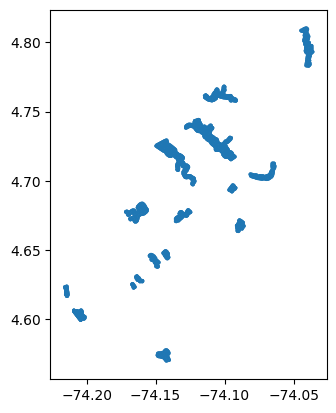

In [19]:
humedales.plot()
plt.show()

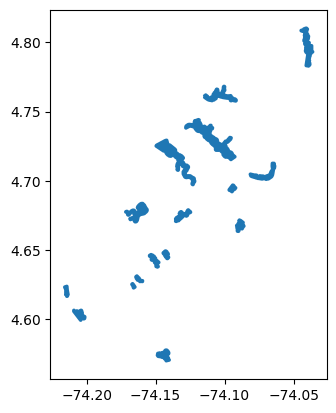

In [22]:
humedales_boundary = humedales.dissolve(by="nombre").reset_index()
humedales_boundary.head(18)
humedales_boundary.plot()
plt.show()

In [21]:
print("Registros capa original:", len(humedales))
print("Registros después del dissolve:", len(humedales_boundary))

Registros capa original: 7112
Registros después del dissolve: 15


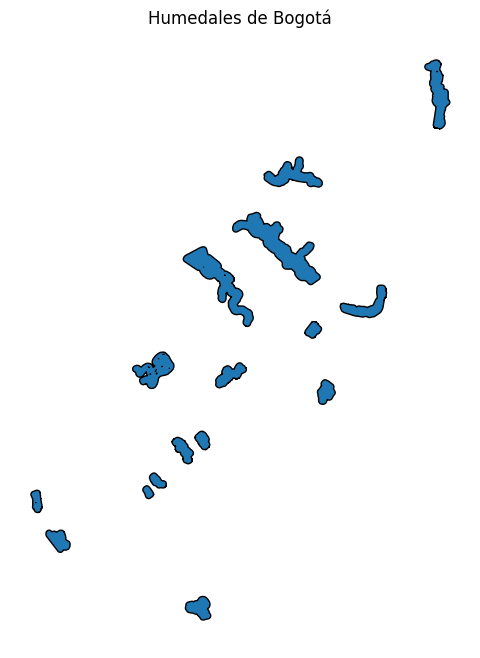

In [24]:
ax = humedales_boundary.plot(
    figsize=(10, 8),
    edgecolor="black"
)

ax.set_title("Humedales de Bogotá")
ax.set_axis_off()
plt.show()

## Guardar el resultado procesado

In [25]:
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)
DATA_EXPORTS.mkdir(parents=True, exist_ok=True)

humedales_boundary.to_file(
    DATA_PROCESSED / "humedales_boundary.gpkg",
    driver="GPKG"
)

humedales_boundary.to_file(
    DATA_EXPORTS / "humedales_boundary.geojson",
    driver="GeoJSON"
)

print("Boundary exportado correctamente.")

Boundary exportado correctamente.
